<a href="https://colab.research.google.com/github/bijoy-420/python-course-project/blob/main/Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Welcome to Cancer Detection with Skill Morph!")
print("We will build a Skill Moprh Doctor to detect breast cancer!")

Welcome to Cancer Detection with Skill Morph!
We will build a Skill Moprh Doctor to detect breast cancer!


# **Introduction**

In [2]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset

In [5]:
print("Reading the real cancer dataset...")
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Breast_Cancer_Wisconsin_Dataset.csv')




Reading the real cancer dataset...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Show first few patients
print("\nFirst 5 patients in our dataset:")
print(data[['id', 'diagnosis', 'radius_mean', 'texture_mean', 'area_mean']].head())

# Understand diagnosis column

print(f"M (Malignant = Dangerous Cancer):  {diagnosis_counts['M']} patients")
print(f"B (Benign = Harmless Cancer):      {diagnosis_counts['B']} patients")
print(f"Total patients:                    {len(data)} patients")


First 5 patients in our dataset:
         id diagnosis  radius_mean  texture_mean  area_mean
0    842302         M        17.99         10.38     1001.0
1    842517         M        20.57         17.77     1326.0
2  84300903         M        19.69         21.25     1203.0
3  84348301         M        11.42         20.38      386.1
4  84358402         M        20.29         14.34     1297.0


NameError: name 'diagnosis_counts' is not defined

# **Prepare Data**

In [8]:

print("Converting M → 1 (Malignant Cancer) and B → 0 (Benign Cancer)")

# Convert diagnosis to numbers
data['diagnosis_numeric'] = data['diagnosis'].map({'M': 1, 'B': 0})


# Select only the most important features (make it simple!)
important_features = [
    'radius_mean',      # Size of tumor
    'texture_mean',     # Surface texture
    'area_mean',        # Area of tumor
    'smoothness_mean',  # How smooth the surface is
    'compactness_mean', # How compact the tumor is
]


# Create simple dataset
X = data[important_features]  # Patient measurements
y = data['diagnosis_numeric']  # Malignant (1) or Benign (0)

print(f"X (measurements): {X.shape}")
print(f"y (diagnosis): {y.shape}")

Converting M → 1 (Malignant Cancer) and B → 0 (Benign Cancer)
X (measurements): (569, 5)
y (diagnosis): (569,)


# **Train and Test Split**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20
)

print(f"Training: {len(X_train)} patients (computer will learn from these)")
print(f"Testing:  {len(X_test)} patients (computer will be tested on these)")

# Show some training examples
print(f"\n Training Examples (Computer learns from these):")
print(X_train.head())

Training: 455 patients (computer will learn from these)
Testing:  114 patients (computer will be tested on these)

 Training Examples (Computer learns from these):
     radius_mean  texture_mean  area_mean  smoothness_mean  compactness_mean
412        9.397         21.68      268.8          0.07969           0.06053
461       27.420         26.27     2501.0          0.10840           0.19880
532       13.680         16.33      575.5          0.09277           0.07255
495       14.870         20.21      680.9          0.09587           0.08345
13        15.850         23.95      782.7          0.08401           0.10020


# **Train with Decision Tree**

In [10]:
# Create our Skill Morph model
skillmorph_doctor = DecisionTreeClassifier(
    max_depth=4,  # Keep it simple - not too complex
    random_state=20
)

print("Teaching Skill Morph doctor with training data...")
# Train the model
skillmorph_doctor.fit(X_train, y_train)
print("Skill Morph doctor training completed!")




Teaching Skill Morph doctor with training data...
Skill Morph doctor training completed!


# **Test our Skill Morph Doctor**

In [11]:

print("Now let's see how good our Skill Morph doctor is...")

# Make predictions
predictions = skillmorph_doctor.predict(X_test)

print("Skill Morph doctor made predictions for all test patients!")


# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"\nSkill Morph Doctor Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

if accuracy > 0.95:
    print("EXCELLENT! Our Skill Morph doctor is very accurate!")
elif accuracy > 0.90:
    print("GOOD! Our Skill Morph doctor performs well!")
elif accuracy > 0.80:
    print("OK! Our Skill Morph doctor is decent!")
else:
    print("Needs improvement...")



Now let's see how good our Skill Morph doctor is...
Skill Morph doctor made predictions for all test patients!

Skill Morph Doctor Accuracy: 0.904 (90.4%)
GOOD! Our Skill Morph doctor performs well!


# Confusion Matrix

Confusion Matrix:
[[62  4]
 [ 7 41]]

Correct: 103
Wrong: 11


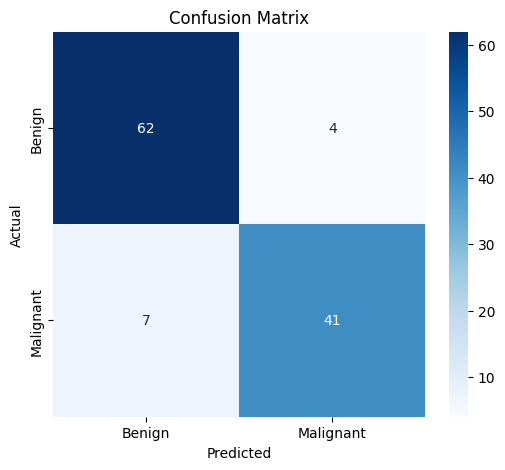

In [12]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, predictions)

# Print it
print("Confusion Matrix:")
print(cm)
print(f"\nCorrect: {cm[0,0] + cm[1,1]}")
print(f"Wrong: {cm[0,1] + cm[1,0]}")

# Plot it
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# **Detailed Performance**

Accuracy:  0.90
Precision: 0.91
Recall:    0.85
F1-Score:  0.88


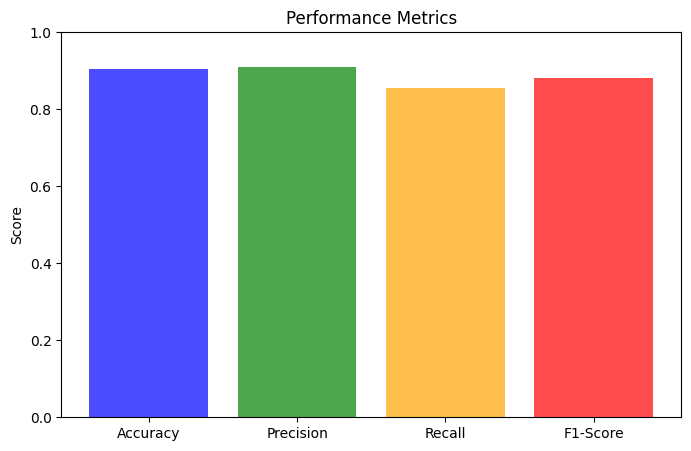

In [13]:
# Calculate metrics
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

# Print them
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")

# Simple bar chart
plt.figure(figsize=(8, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red'], alpha=0.7)
plt.ylim(0, 1)
plt.title('Performance Metrics')
plt.ylabel('Score')
plt.show()

Assignment

In [14]:
# Question 1: Find the Best Tree Depth

# Task: Test depths 2, 3, 4, 5 and find highest accuracy


# Question 2: Calculate All Metrics

# Task: Use best depth to calculate precision, recall, F1-score


# Question 3: Test on New Patients


# Question 4: Analyze Confusion Matrix

# #test depth 2

In [15]:
# Create our Skill Morph model
skillmorph_doctor2 = DecisionTreeClassifier(
    max_depth=2,  # Keep it simple - not too complex
    random_state=20
)

print("Teaching Skill Morph doctor with training data...")
# Train the model
skillmorph_doctor2.fit(X_train, y_train)
print("Skill Morph doctor training completed!")


print("Now let's see how good our Skill Morph doctor is...")

# Make predictions
predictions = skillmorph_doctor2.predict(X_test)

print("Skill Morph doctor made predictions for all test patients!")


# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"\nSkill Morph Doctor Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

if accuracy > 0.95:
    print("EXCELLENT! Our Skill Morph doctor is very accurate!")
elif accuracy > 0.90:
    print("GOOD! Our Skill Morph doctor performs well!")
elif accuracy > 0.80:
    print("OK! Our Skill Morph doctor is decent!")
else:
    print("Needs improvement...")




Teaching Skill Morph doctor with training data...
Skill Morph doctor training completed!
Now let's see how good our Skill Morph doctor is...
Skill Morph doctor made predictions for all test patients!

Skill Morph Doctor Accuracy: 0.851 (85.1%)
OK! Our Skill Morph doctor is decent!


# #test depth 3

In [19]:
skillmorph_doctor3=DecisionTreeClassifier(
    max_depth=3,
    random_state=20
)

skillmorph_doctor3.fit(X_train,y_train)
prediction3=skillmorph_doctor3.predict(X_test)
accuracy3=accuracy_score(y_test,prediction3)
print(f'accuracy score:',accuracy3)

if accuracy3>0.95:
  print("EXCELLENT! Our Skill Morph doctor is very accurate!")
elif accuracy3>0.90:
  print("GOOD! Our Skill Morph doctor performs well!")

elif accuracy3>0.80:
  print("OK! Our Skill Morph doctor is decent!")
else:
  print("Needs improvement...")



accuracy score: 0.8859649122807017
OK! Our Skill Morph doctor is decent!


# #test depth 4

In [23]:
skillmorph_doctor4=DecisionTreeClassifier(
    max_depth=4,
    random_state=20
)

skillmorph_doctor4.fit(X_train,y_train)
prediction4=skillmorph_doctor4.predict(X_test)
accuracy4=accuracy_score(y_test,prediction4)
print(f'accuracy score:',accuracy4)

if accuracy3>0.95:
  print("EXCELLENT! Our Skill Morph doctor is very accurate!")
elif accuracy3>0.90:
  print("GOOD! Our Skill Morph doctor performs well!")

elif accuracy3>0.80:
  print("OK! Our Skill Morph doctor is decent!")
else:
  print("Needs improvement...")



accuracy score: 0.9035087719298246
OK! Our Skill Morph doctor is decent!


# #test depth 5

In [24]:
skillmorph_doctor5=DecisionTreeClassifier(
    max_depth=5,
    random_state=20
)

skillmorph_doctor5.fit(X_train,y_train)
prediction5=skillmorph_doctor5.predict(X_test)
accuracy5=accuracy_score(y_test,prediction5)
print(f'accuracy score:',accuracy5)

if accuracy3>0.95:
  print("EXCELLENT! Our Skill Morph doctor is very accurate!")
elif accuracy3>0.90:
  print("GOOD! Our Skill Morph doctor performs well!")

elif accuracy3>0.80:
  print("OK! Our Skill Morph doctor is decent!")
else:
  print("Needs improvement...")



accuracy score: 0.8947368421052632
OK! Our Skill Morph doctor is decent!


# #Best score tree depth 4

In [27]:
print(f'precision_score:',precision_score(y_test,prediction4))
print(f'recall_score:',recall_score(y_test,prediction4))
print(f'F1_score:',f1_score(y_test,prediction4))

precision_score: 0.9111111111111111
recall_score: 0.8541666666666666
F1_score: 0.8817204301075269


# #Test on New Patients

In [29]:
data.head(2)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32,diagnosis_numeric
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN,1
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN,1


## Define Prediction Function



In [39]:
def predict_diagnosis(patient_data):

    new_patient_df = pd.DataFrame([patient_data])

    important_features = [
        'radius_mean',
        'texture_mean',
        'area_mean',
        'smoothness_mean',
        'compactness_mean',
    ]
    new_patient_df = new_patient_df[important_features]

    prediction = skillmorph_doctor4.predict(new_patient_df)

    if prediction[0] == 1:
        return "Malignant"
    else:
        return "Benign"

print("Prediction function 'predict_diagnosis' defined.")

Prediction function 'predict_diagnosis' defined.


In [40]:

new_data = {
    'radius_mean': 17.99,
    'texture_mean': 10.38,
    'area_mean': 1001.0,
    'smoothness_mean': 0.11840,
    'compactness_mean': 0.27760
}

predicted_diagnosis = predict_diagnosis(new_data)

print(f"Predicted Diagnosis: {predicted_diagnosis}")


Predicted Diagnosis: Malignant


# #Analyze The Confusion Matrix

[[62  4]
 [ 7 41]]

Correct: 103
wrong: 11


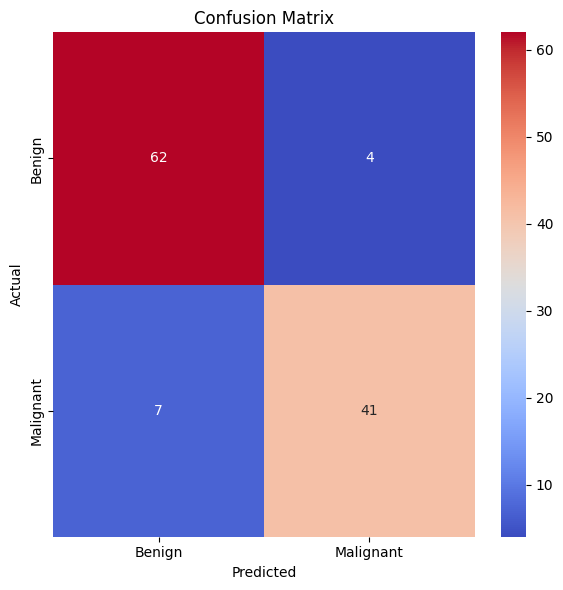

In [54]:

cm=confusion_matrix(y_test,prediction4)
print(cm)
print(f"\nCorrect: {cm[0,0] +cm[1,1]}")
print(f"wrong: {cm[0,1] +cm[1,0]}")

plt.figure(figsize=(6, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()